In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [3]:
from package_files.benefits_defns import *

In [8]:
coeff_df = pd.read_csv('../exports/occ_year_data/occ_year_analysis_remotekw.csv')

In [14]:
coeff_df

,SOC_2021_2_NAME,YEAR,AI Demand,MEAN SALARY,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,DURATION_CALC_ai,MEDIAN_LOG_SALARY_ai,...,Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI),Prevalence: Remote Keywords,Prevalence: Remote Keywords (AI),Prevalence: Remote Keywords (Non-AI),Log Job Count
0,Architecture and Engineering Occupations,2018,1.626858,72708.646776,NaN,NaN,11.279748,85233.255814,64.000000,11.329003,...,4.777047,7.121212,4.738280,0.000000,NaN,0.000000,1.971949,1.363636,1.982009,10.610760
1,Architecture and Engineering Occupations,2019,2.031486,73966.078049,24.871731,NaN,11.443344,97865.619048,61.510441,11.461632,...,5.568910,10.788863,5.460669,2.348773,3.415783,2.326330,2.104544,3.944316,2.066394,10.655658
2,Architecture and Engineering Occupations,2020,1.977806,72858.029585,-2.642404,24.871731,11.428493,100957.585366,60.158371,11.487608,...,6.691128,18.853695,6.445723,4.442167,13.698630,4.255188,3.872084,11.915535,3.709790,10.419957
3,Architecture and Engineering Occupations,2021,2.278018,73671.056972,15.179062,-2.642404,11.521036,107050.060606,61.420229,11.556942,...,10.442301,24.400417,10.116921,8.357362,14.465409,8.215270,6.670151,9.176225,6.611731,10.647756
4,Architecture and Engineering Occupations,2022,2.446456,83890.460953,7.394079,15.179062,11.600475,115932.657459,54.149606,11.556942,...,15.806525,35.146743,15.321509,14.685004,18.168605,14.597810,10.475807,13.886901,10.390263,10.952612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Transportation and Material Moving Occupations,2019,0.033652,44182.104241,-18.600785,NaN,10.485831,38192.625000,59.806452,10.450209,...,2.248155,3.225806,2.247825,0.385060,0.000000,0.385194,0.574251,0.000000,0.574444,11.430847
86,Transportation and Material Moving Occupations,2020,0.026921,42269.295590,-20.001353,-18.600785,10.529685,40678.900000,55.210526,10.404093,...,2.021905,5.263158,2.021032,0.565415,0.000000,0.565566,0.590136,0.000000,0.590295,11.857607
87,Transportation and Material Moving Occupations,2021,0.067199,46920.261844,149.616383,-20.001353,10.663532,48247.636364,66.026549,10.520992,...,5.318839,32.743363,5.300398,0.769559,3.539823,0.767678,0.772492,2.654867,0.771227,12.032653
88,Transportation and Material Moving Occupations,2022,0.085570,48729.813507,27.338156,149.616383,10.630348,47164.969697,56.700855,10.473337,...,9.225481,29.059829,9.208494,0.806475,14.655172,0.794634,0.964675,9.401709,0.957449,11.825763


In [9]:
coeff_df.columns

Index(['SOC_2021_2_NAME', 'YEAR', 'AI Demand', 'MEAN SALARY',
       'AI Demand % Change', 'PRIOR YEAR % CHANGE', 'LOG_SALARY_ai',
       'SALARY_ai', 'DURATION_CALC_ai', 'MEDIAN_LOG_SALARY_ai',
       'MEDIAN_SALARY_ai', 'LOG_SALARY_non_ai', 'SALARY_non_ai',
       'DURATION_CALC_non_ai', 'MEDIAN_LOG_SALARY_non_ai',
       'MEDIAN_SALARY_non_ai', 'Salary (Log) Premium', 'SALARY_PREMIUM',
       'job_count', 'Prevalence: Tuition Assistance',
       'Prevalence: Tuition Assistance (AI)',
       'Prevalence: Tuition Assistance (Non-AI)', 'Prevalence: Paid Leave',
       'Prevalence: Paid Leave (AI)', 'Prevalence: Paid Leave (Non-AI)',
       'Prevalence: Health and Wellbeing',
       'Prevalence: Health and Wellbeing (AI)',
       'Prevalence: Health and Wellbeing (Non-AI)',
       'Prevalence: Parental Leave', 'Prevalence: Parental Leave (AI)',
       'Prevalence: Parental Leave (Non-AI)', 'Prevalence: Workplace Culture',
       'Prevalence: Workplace Culture (AI)',
       'Prevalence: 

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

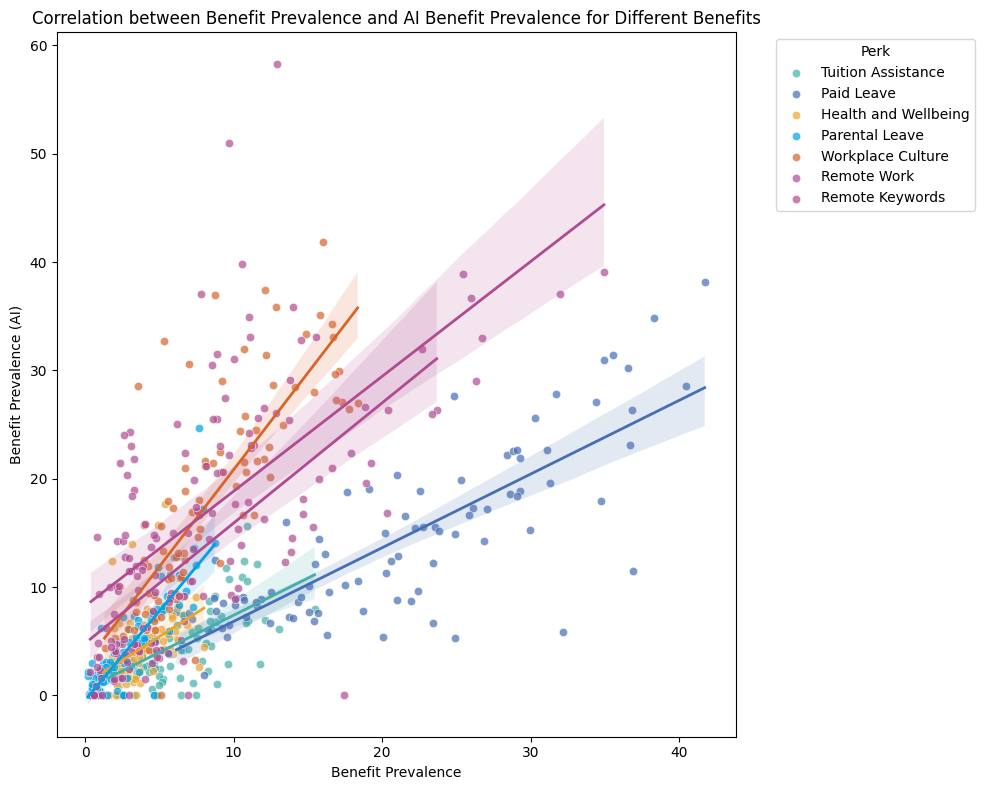

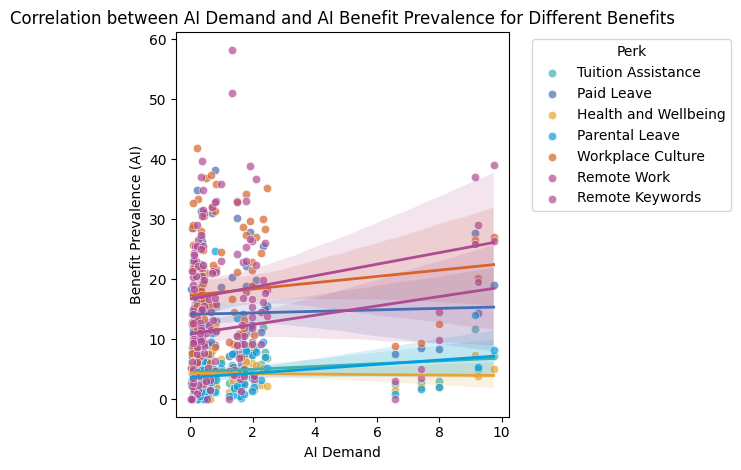

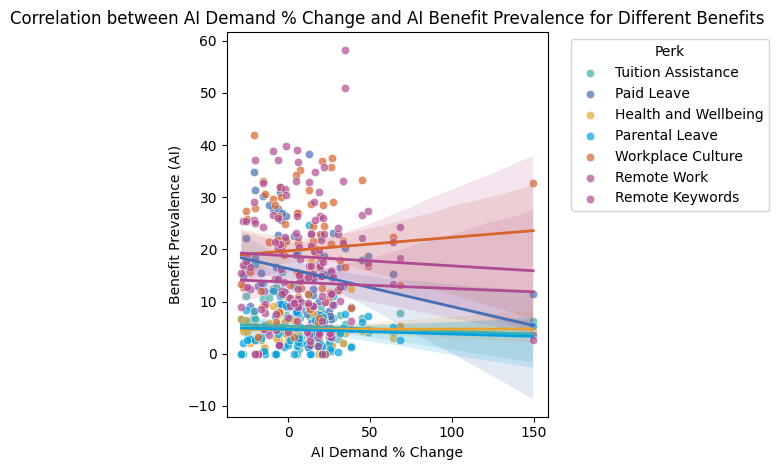

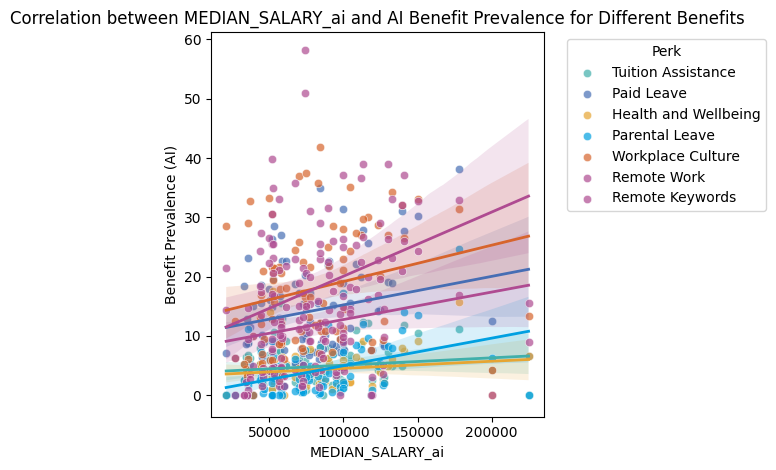

In [26]:
# Set the colors for different perks
palette = list(benefit_colors.values())

plt.figure(figsize=(10, 8))  # Set the overall figure size

for x in range(4):
    for i, benefit in enumerate(benefits4):
        x_factors = [f'Benefit Prevalence', 'AI Demand', 'AI Demand % Change', 'MEDIAN_SALARY_ai']
        benefit_df = coeff_df[[f'Prevalence: {benefits_labels_map[benefit]} (AI)', f'Prevalence: {benefits_labels_map[benefit]}', 'AI Demand', 'AI Demand % Change', 'MEDIAN_SALARY_ai']].copy()
        benefit_df.rename(columns = {f'Prevalence: {benefits_labels_map[benefit]} (AI)': 'Benefit Prevalence (AI Roles)', f'Prevalence: {benefits_labels_map[benefit]}': 'Benefit Prevalence'}, inplace=True)
        factor = x_factors[x]
        benefit_df = benefit_df.dropna(subset=[factor, f'Benefit Prevalence (AI Roles)'])
        # Remove outliers if needed
        # scatter_df = remove_outliers(benefit_df, 'AI Coefficient').copy()
        scatter_df = benefit_df.copy()
        # Plot scatter points for this perk
        sns.scatterplot(
            data=scatter_df,
            x=x_factors[x],
            y=f'Benefit Prevalence (AI Roles)',
            color=palette[i],  # Use a specific color for this perk
            label=benefits4_labels[i],  # Label for the legend
            alpha=0.7      # Set some transparency for better visibility
        )

        # Plot a fitted line (regression) for this perk
        sns.regplot(
            data=scatter_df,
            x=x_factors[x],
            y=f'Benefit Prevalence (AI Roles)',
            scatter=False,      # No scatter points for the regression line
            color=palette[i],   # Set the color to match the perk
            line_kws={'label': benefits4_labels[i], 'linewidth': 2}  # Add the perk label to the fitted line
        )

    # Add labels and title to the combined plot
    plt.xlabel(factor)
    plt.ylabel('Benefit Prevalence (AI)')
    plt.title(f'Correlation between {factor} and AI Benefit Prevalence for Different Benefits')

    # Add a legend that shows the perks
    plt.legend(title='Perk', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Display the final combined plot
    plt.tight_layout()
    plt.show()
